In [48]:
import json
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# import seaborn as sns

import tensorflow as tf
from tensorflow import keras

from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve)

tf.random.set_seed(42)
np.random.seed(42)


In [49]:
train_df = pd.read_csv('heart_disease_train.csv')
test_df = pd.read_csv('heart_disease_test.csv')
val_df = pd.read_csv('heart_disease_val.csv')

X_train = train_df.drop(columns=['Heart_Disease']).values.astype(np.float32)
y_train = train_df['Heart_Disease'].values.astype(np.float32)

X_val = val_df.drop(columns=['Heart_Disease']).values.astype(np.float32)
y_val = val_df['Heart_Disease'].values.astype(np.float32)

X_test = test_df.drop(columns=['Heart_Disease']).values.astype(np.float32)
y_test = test_df['Heart_Disease'].values.astype(np.float32)

print(f"Train: {X_train.shape}")
print(f"Val:   {X_val.shape}")
print(f"Test:  {X_test.shape}")
print(f"Number of features: {X_train.shape[1]}")

Train: (18627, 16)
Val:   (5285, 16)
Test:  (5979, 16)
Number of features: 16


In [50]:
with open('heart_disease_metadata.json') as f:
    metadata = json.load(f)

feature_cols = metadata['feature_cols']
scaler_mean = np.array(metadata['scaler_mean'], dtype=np.float32)
scaler_scale = np.array(metadata['scaler_scale'], dtype=np.float32)

print(f"Loaded metadata for {len(feature_cols)} features")

scaler_scale


Loaded metadata for 16 features


array([14.490715  ,  0.49998444,  6.3466773 ,  0.7975433 ,  0.74745375,
        0.8748711 ,  0.8941631 ,  0.45809102,  0.4003057 ,  0.43613592,
        0.4909653 ,  0.2991607 , 23.09571   , 17.249577  , 31.678753  ,
       43.04224   ], dtype=float32)

In [51]:
def build_ann(n_features):
    inputs = keras.Input(shape=(n_features,), name='features')

    # Block 1
    x = keras.layers.Dense(128, kernel_regularizer=keras.regularizers.l2(1e-4))(inputs)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.Activation('relu')(x)
    x = keras.layers.Dropout(0.3)(x)

    # Block 2
    x = keras.layers.Dense(64, kernel_regularizer=keras.regularizers.l2(1e-4))(x)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.Activation('relu')(x)
    x = keras.layers.Dropout(0.3)(x)

    # Block 3
    x = keras.layers.Dense(32)(x)
    x = keras.layers.Activation('relu')(x)
    x = keras.layers.Dropout(0.2)(x)

    # Output: a single probability
    outputs = keras.layers.Dense(1, activation='sigmoid', name='prob')(x)

    return keras.Model(inputs, outputs, name='Heart_Disease_ANN')


model = build_ann(X_train.shape[1])
model.summary()

Model: "Heart_Disease_ANN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ features (InputLayer)           │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │         2,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_12 (Activation)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_13 (Activation)      │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_14 (Activation)      │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ prob (Dense)                    │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,313 (52.00 KB)

 Trainable params: 12,929 (50.50 KB)

 Non-trainable params: 384 (1.50 KB)

In [52]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=5e-4),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        keras.metrics.AUC(name='auc'),
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall'),
    ]
)


print(X_val.shape)
print(y_val.shape)

(5285, 16)
(5285,)


In [53]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_auc', patience=25,
        restore_best_weights=True, mode='max', verbose=1),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_auc', factor=0.5, patience=10,
        min_lr=1e-6, mode='max', verbose=1),
    keras.callbacks.ModelCheckpoint(
        'best_heart_disease.keras', monitor='val_auc',
        save_best_only=True, mode='max', verbose=0),
]

history = model.fit(
    X_train, y_train,
    epochs=300, batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    verbose=1,
)

print(f"\nEpochs run:   {len(history.history['loss'])}")
print(f"Best val AUC: {max(history.history['val_auc']):.4f}")


Epoch 1/300
583/583 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8337 - auc: 0.9203 - loss: 0.3673 - precision: 0.8169 - recall: 0.8270 - val_accuracy: 0.9256 - val_auc: 0.9830 - val_loss: 0.1895 - val_precision: 0.9140 - val_recall: 0.9270 - learning_rate: 5.0000e-04
Epoch 2/300
583/583 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8979 - auc: 0.9642 - loss: 0.2530 - precision: 0.8910 - recall: 0.8888 - val_accuracy: 0.9321 - val_auc: 0.9856 - val_loss: 0.1732 - val_precision: 0.9225 - val_recall: 0.9319 - learning_rate: 5.0000e-04
Epoch 3/300
583/583 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.9089 - auc: 0.9708 - loss: 0.2291 - precision: 0.8992 - recall: 0.9052 - val_accuracy: 0.9360 - val_auc: 0.9873 - val_loss: 0.1627 - val_precision: 0.9259 - val_recall: 0.9372 - learning_rate: 5.0000e-04
Epoch 4/300
583/583 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.9110 - auc: 0.9736 - loss: 0.2183 - precision: 0.9006 - recall: 0.9086 - val_accuracy: 0.9417 - val_auc: 0.9891 - va

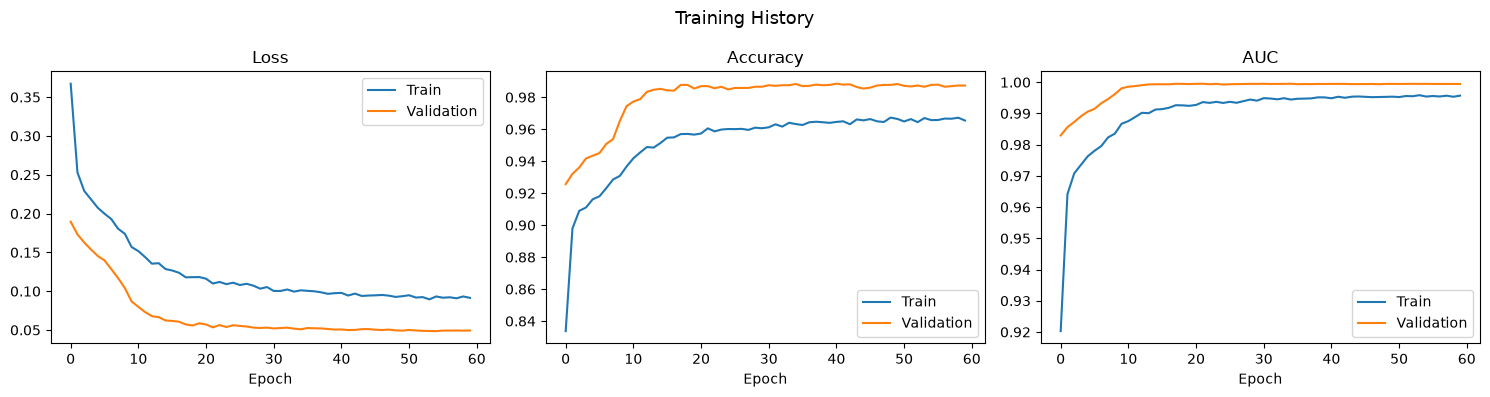

In [54]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history.history['loss'], label='Train')
axes[0].plot(history.history['val_loss'], label='Validation')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['accuracy'], label='Train')
axes[1].plot(history.history['val_accuracy'], label='Validation')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()

axes[2].plot(history.history['auc'], label='Train')
axes[2].plot(history.history['val_auc'], label='Validation')
axes[2].set_title('AUC')
axes[2].set_xlabel('Epoch')
axes[2].legend()

plt.suptitle('Training History', fontsize=13)
plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()

In [55]:
model.load_weights('best_heart_disease.keras')

test_results = model.evaluate(X_test, y_test, verbose=0)
for name, value in zip(model.metrics_names, test_results):
    print(f"{name:<12}: {value:.4f}")

loss        : 0.0517
compile_metrics: 0.9913


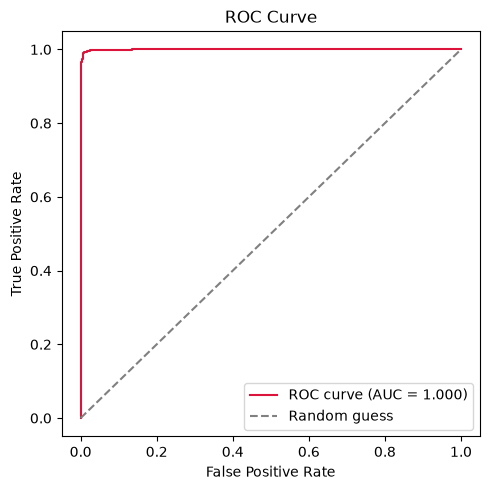

ROC-AUC: 0.9995


In [56]:
y_prob = model.predict(X_test, verbose=0).flatten()
auc_score = roc_auc_score(y_test, y_prob)

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, color='crimson', label=f'ROC curve (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"ROC-AUC: {auc_score:.4f}")

                  precision    recall  f1-score   support

No Heart Disease       0.99      0.99      0.99      3205
   Heart Disease       0.99      0.99      0.99      2774

        accuracy                           0.99      5979
       macro avg       0.99      0.99      0.99      5979
    weighted avg       0.99      0.99      0.99      5979



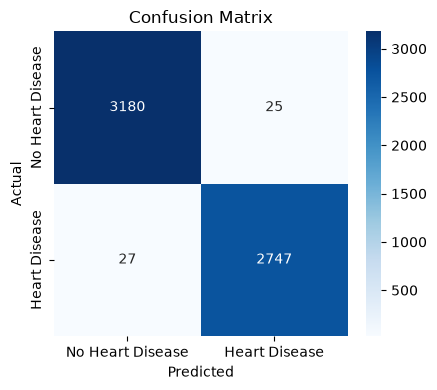

In [57]:
y_pred = (y_prob >= 0.5).astype(int)
import seaborn as sns

print(classification_report(y_test, y_pred, target_names=['No Heart Disease', 'Heart Disease']))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Heart Disease', 'Heart Disease'],
            yticklabels=['No Heart Disease', 'Heart Disease'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [58]:
model.save('Heart_Disease_ann.keras')

with open('Heart_Disease_inference_kit.pkl', 'wb') as f:
    pickle.dump({
         'scaler_mean': scaler_mean,
        'scaler_scale': scaler_scale,
        'feature_cols': feature_cols,
    }, f)

print("Saved Heart_Disease_ann.keras")
print("Saved Heart_Disease_inference_kit.pkl")

Saved Heart_Disease_ann.keras
Saved Heart_Disease_inference_kit.pkl


In [59]:
def predict_patient(patient, model, FEATURES, scaler_mean, scaler_scale):
    patient = patient.copy()

    # Put the features in the exact same order the model expects
    row = np.array([patient[col] for col in feature_cols], dtype=np.float32)

    # Scale by hand: same formula the training data went through
    row_scaled = (row - scaler_mean) / scaler_scale
    row_scaled = row_scaled.reshape(1, -1)

    probability = model.predict(row_scaled, verbose=0)[0][0]
    prediction = 'Heart_Disease' if probability >= 0.5 else 'No_Heart_Disease'

    print(f"Probability of Heart_Disease: {probability:.1%}")
    print(f"Prediction: {prediction}")


In [60]:
patient_1 = {
    "Age":25,	
    "Gender":0,
    "BMI":33.0,
    "Smoking":2,
    "Alcohol_Intake":0,
    "Physical_Activity":1,
    "Stress_Level":1,
    "Hypertension":0,
    "Diabetes":1,
    "Hyperlipidemia":0,
    "Family_History":1,
    "Previous_Heart_Attack":0,
    "Systolic_BP":90,
    "Diastolic_BP":72,
    "Blood_Sugar_Fasting":20,
    "Heart_Rate":90,
    "Cholesterol_Total":246
    }
print("Patient 1 (actual: No Heart Disease)")
predict_patient(patient_1, model, feature_cols, scaler_mean, scaler_scale)

print()

patient_2 = {
    "Age":75,	
    "Gender":1,
    "BMI":37.4,
    "Smoking":2,
    "Alcohol_Intake":1,
    "Physical_Activity":1,
    "Stress_Level":1,
    "Hypertension":0,
    "Diabetes":0,
    "Hyperlipidemia":1,
    "Family_History":1,
    "Previous_Heart_Attack":1,
    "Systolic_BP":171,
    "Diastolic_BP":92,
    "Blood_Sugar_Fasting":280,
    "Heart_Rate":105,
    "Cholesterol_Total":290
}
print("Patient 2 (actual: Heart Disease)")
predict_patient(patient_2, model, feature_cols, scaler_mean, scaler_scale)

Patient 1 (actual: No Heart Disease)
Probability of Heart_Disease: 70.7%
Prediction: Heart_Disease

Patient 2 (actual: Heart Disease)
Probability of Heart_Disease: 100.0%
Prediction: Heart_Disease
